<a href="https://colab.research.google.com/github/rahaf7777/melanoma/blob/main/melanoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

In [ ]:
import os

In [ ]:
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

In [ ]:
os.makedirs('/content/drive/MyDrive/melanoma_v2', exist_ok=True)
os.chdir('/content/drive/MyDrive/melanoma_v2')

In [ ]:
os.system('kaggle datasets download -d hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images --unzip')

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/melanoma_v2'
print("Contents of melanoma_v2:")
print(os.listdir(dataset_path))

In [ ]:
inner_path = '/content/drive/MyDrive/melanoma_v2/melanoma_cancer_dataset'
print("Contents:", os.listdir(inner_path))

In [ ]:
train_path = os.path.join(inner_path, 'train')
test_path = os.path.join(inner_path, 'test')

In [ ]:
print("\nTrain folder contents:", os.listdir(train_path))
print("Test folder contents:", os.listdir(test_path))

In [ ]:
train_benign = os.listdir(os.path.join(train_path, 'benign'))
train_malignant = os.listdir(os.path.join(train_path, 'malignant'))
test_benign = os.listdir(os.path.join(test_path, 'benign'))
test_malignant = os.listdir(os.path.join(test_path, 'malignant'))

In [ ]:
print("Train - benign:", len(train_benign))
print("Train - malignant:", len(train_malignant))
print("Test - benign:", len(test_benign))
print("Test - malignant:", len(test_malignant))
print("\nTotal images:", len(train_benign) + len(train_malignant) + len(test_benign) + len(test_malignant))

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

In [ ]:
benign_files = os.listdir(os.path.join(train_path, 'benign'))[:3]
malignant_files = os.listdir(os.path.join(train_path, 'malignant'))[:3]

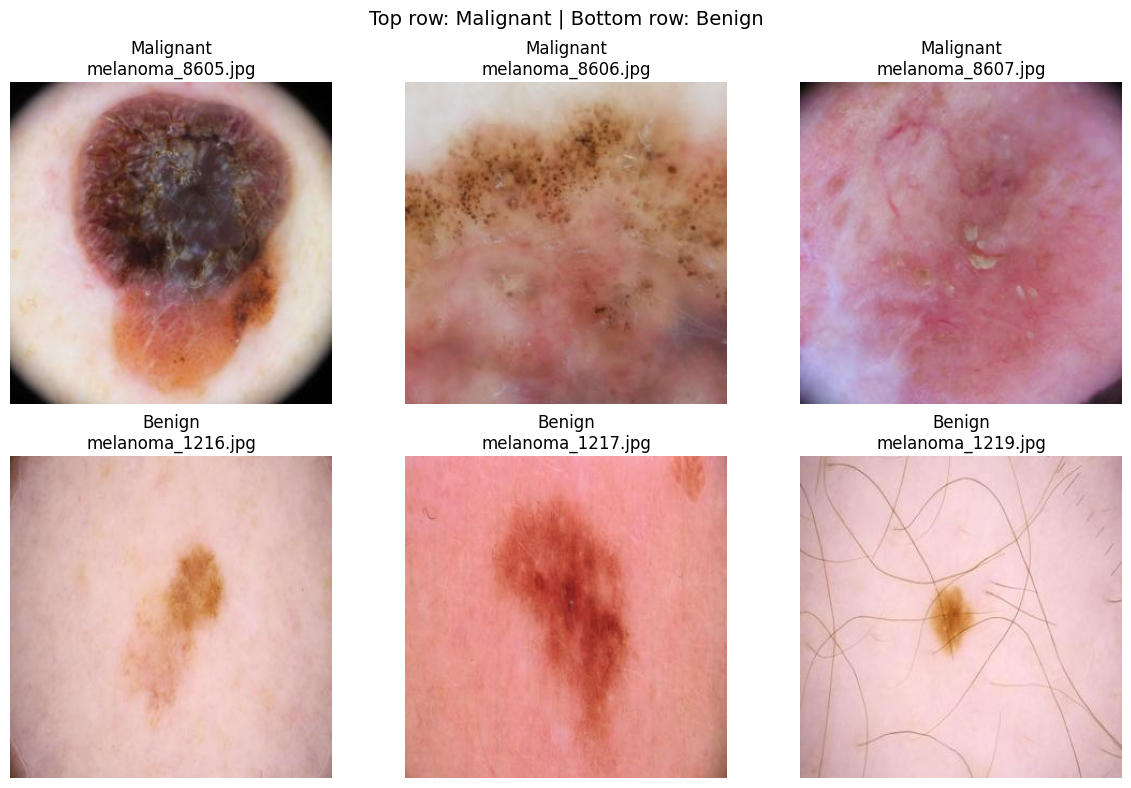

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Top row: Malignant | Bottom row: Benign', fontsize=14)

for i, filename in enumerate(malignant_files):
    img_path = os.path.join(train_path, 'malignant', filename)
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Malignant\n{filename}')
    axes[0, i].axis('off')

for i, filename in enumerate(benign_files):
    img_path = os.path.join(train_path, 'benign', filename)
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Benign\n{filename}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
sample_img = Image.open(os.path.join(train_path, 'malignant', malignant_files[0]))
print("Image size:", sample_img.size)
print("Image mode:", sample_img.mode)

Image size: (300, 300)
Image mode: RGB


In [ ]:
import pandas as pd
import os

In [ ]:
def build_dataframe(base_path, split_name):
  records = []

In [ ]:
def build_dataframe(base_path, split_name):

    records = []
    for label_name, target_value in [('benign', 0), ('malignant', 1)]:
        class_folder = os.path.join(base_path, label_name)
        filenames = os.listdir(class_folder)

        for filename in filenames:
            full_path = os.path.join(class_folder, filename)
            records.append({
                'image_path': full_path,
                'target': target_value,
                'split': split_name
            })

    return pd.DataFrame(records)

df_train = build_dataframe(train_path, 'train')
df_test = build_dataframe(test_path, 'test')

df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Total images:", len(df_all))
print("\nClass distribution:")
print(df_all['target'].value_counts())
print("\nSplit distribution:")
print(df_all['split'].value_counts())
print("\nSample rows:")
print(df_all.head())

Total images: 10605

Class distribution:
target
0    5500
1    5105
Name: count, dtype: int64

Split distribution:
split
train    9605
test     1000
Name: count, dtype: int64

Sample rows:
                                          image_path  target  split
0  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
1  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
2  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
3  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
4  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train


In [ ]:
df_all['exists'] = df_all['image_path'].apply(os.path.exists)

print("Total images:", len(df_all))
print("Missing images:", (~df_all['exists']).sum())

Total images: 10605
Missing images: 0


In [ ]:
df_all = df_all.drop(columns=['exists'])
df_all.to_csv('/content/drive/MyDrive/melanoma_v2/final_metadata.csv', index=False)
print("Saved final_metadata.csv!")
print("Final shape:", df_all.shape)

Saved final_metadata.csv!
Final shape: (10605, 3)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_trainval = df_all[df_all['split'] == 'train'].copy()
df_test_final = df_all[df_all['split'] == 'test'].copy()

df_train_final, df_val_final = train_test_split(
    df_trainval,
    test_size=0.2,
    stratify=df_trainval['target'],
    random_state=42
)

print("Train size:", len(df_train_final))
print("Validation size:", len(df_val_final))
print("Test size (untouched):", len(df_test_final))

print("\nTrain class balance:")
print(df_train_final['target'].value_counts(normalize=True))

print("\nValidation class balance:")
print(df_val_final['target'].value_counts(normalize=True))

Train size: 7684
Validation size: 1921
Test size (untouched): 1000

Train class balance:
target
0    0.520562
1    0.479438
Name: proportion, dtype: float64

Validation class balance:
target
0    0.520562
1    0.479438
Name: proportion, dtype: float64


In [ ]:
df_train_final.to_csv('/content/drive/MyDrive/melanoma_v2/train_split.csv', index=False)
df_val_final.to_csv('/content/drive/MyDrive/melanoma_v2/val_split.csv', index=False)
df_test_final.to_csv('/content/drive/MyDrive/melanoma_v2/test_split.csv', index=False)

print("All three splits saved!")

All three splits saved!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_final['target']),
    y=df_train_final['target']
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9605), 1: np.float64(1.0428881650380022)}


In [ ]:
import tensorflow as tf

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

print("Augmentation pipeline created!")

Augmentation pipeline created!


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

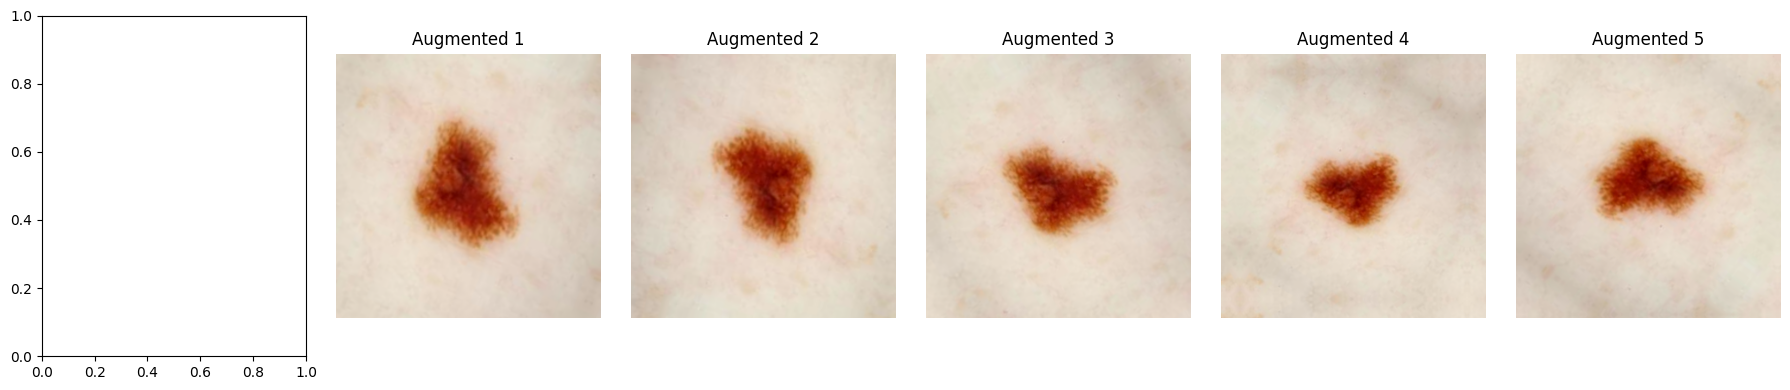

In [ ]:
sample_path = df_train_final[df_train_final['target'] == 1]['image_path'].iloc[0]
sample_img = Image.open(sample_path)
sample_array = np.array(sample_img)

sample_array = np.expand_dims(sample_array, axis=0)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i in range(1, 6):
    augmented = data_augmentation(sample_array, training=True)  # training=True activates the randomness
    axes[i].imshow(augmented[0].numpy().astype("uint8"))
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

+ transfer learning +

In [ ]:
from google.colab import drive
import pandas as pd
import os

In [ ]:
drive.mount('/content/drive')

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/melanoma_v2/train_split.csv')
df_val = pd.read_csv('/content/drive/MyDrive/melanoma_v2/val_split.csv')
df_test = pd.read_csv('/content/drive/MyDrive/melanoma_v2/test_split.csv')

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))
print("\nReady to go!")

In [ ]:
import tensorflow as tf

In [ ]:
IMAGE_SIZE = (300,300)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_image(image_path, label):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, IMAGE_SIZE)
  image = tf.cast(image, tf.float32) / 255.0

  return image, label

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [ ]:
def load_and_augment(image_path, label):
  image, label = load_image(image_path, label)
  image = tf.expand_dims(image, axis=0)
  image = data_augmentation(image, training=True)
  image = tf.squeeze(image, axis=0)

  return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (df_train['image_path'].values, df_train['target'].values)
)
train_dataset = (train_dataset
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (df_val['image_path'].values, df_val['target'].values)
)
val_dataset = (val_dataset
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Train batches:", len(train_dataset))
print("Val batches:", len(val_dataset))
print("\nData pipeline ready!")

In [ ]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
     base_model,
     tf.keras.layers.GlobalAveragePooling2D(),
     tf.keras.layers.Dropout(0.3),
     tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
model.summary()

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/melanoma_v2/best_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

print("\nTraining complete!")

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5167 - auc: 0.5187 - loss: 0.6984
Epoch 1: val_auc improved from None to 0.65801, saving model to /content/drive/MyDrive/melanoma_v2/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/melanoma_v2/best_model.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1675s 6s/step - accuracy: 0.5095 - auc: 0.5109 - loss: 0.6989 - val_accuracy: 0.4794 - val_auc: 0.6580 - val_loss: 0.6996 - learning_rate: 0.0010
Epoch 2/20
 75/241 ━━━━━━━━━━━━━━━━━━━━ 2:26 880ms/step - accuracy: 0.5141 - auc: 0.5184 - loss: 0.6989

In [ ]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/melanoma_v2/best_model.keras'
)

In [ ]:
base_model = model.layers[0]
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
trainable_count = sum([1 for l in base_model.layers if l.trainable])
frozen_count = sum([1 for l in base_model.layers if not l.trainable])
print(f"Trainable layers: {trainable_count}")
print(f"Frozen layers: {frozen_count}")

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:
history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint_ft, early_stopping_ft, reduce_lr_ft]
)

print("\nFine-tuning complete!")

In [ ]:
history_ft2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint_ft, early_stopping_ft, reduce_lr_ft]
)

print("\nRound 2 training complete!")

In [2]:
from google.colab import drive
import pandas as pd
import tensorflow as tf
import os

drive.mount('/content/drive')

df_train = pd.read_csv('/content/drive/MyDrive/melanoma_v2/train_split.csv')
df_val = pd.read_csv('/content/drive/MyDrive/melanoma_v2/val_split.csv')
df_test = pd.read_csv('/content/drive/MyDrive/melanoma_v2/test_split.csv')

print("Splits loaded!")
print("Train:", len(df_train), "| Val:", len(df_val), "| Test:", len(df_test))

Mounted at /content/drive
Splits loaded!
Train: 7684 | Val: 1921 | Test: 1000


In [3]:
import tensorflow as tf

IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

def load_and_augment(image_path, label):
    image, label = load_image(image_path, label)
    image = tf.expand_dims(image, axis=0)
    image = data_augmentation(image, training=True)
    image = tf.squeeze(image, axis=0)
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices(
    (df_train['image_path'].values, df_train['target'].values)
)
train_dataset = (train_dataset
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (df_val['image_path'].values, df_val['target'].values)
)
val_dataset = (val_dataset
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (df_test['image_path'].values, df_test['target'].values)
)
test_dataset = (test_dataset
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Pipeline ready!")
print("Test batches:", len(test_dataset))

Pipeline ready!
Test batches: 32


In [4]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras'
)

print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,896,488 (68.27 MB)

 Trainable params: 3,555,707 (13.56 MB)

 Non-trainable params: 7,229,365 (27.58 MB)

 Optimizer params: 7,111,416 (27.13 MB)

32/32 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step
TEST SET EVALUATION RESULTS
Test AUC:      0.9215

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.72      0.81       500
   Malignant       0.77      0.93      0.84       500

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.83      0.83      1000



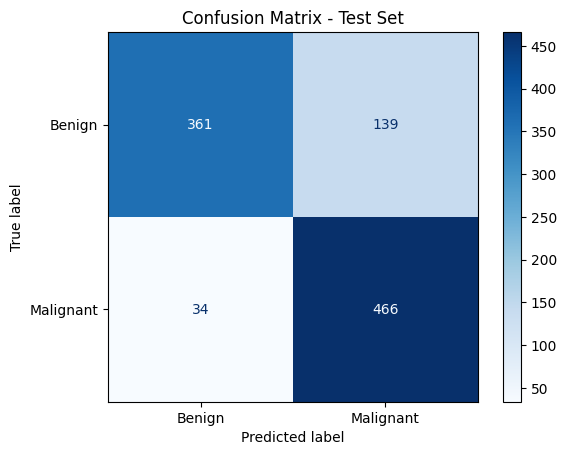


Confusion matrix saved to Drive!


In [5]:
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt


y_pred_probs = model.predict(test_dataset)
y_pred_probs = y_pred_probs.flatten()


y_pred = (y_pred_probs >= 0.5).astype(int)

y_true = df_test['target'].values

auc_score = roc_auc_score(y_true, y_pred_probs)

print("=" * 40)
print("TEST SET EVALUATION RESULTS")
print("=" * 40)
print(f"Test AUC:      {auc_score:.4f}")
print()

print("Classification Report:")
print(classification_report(y_true, y_pred,
                            target_names=['Benign', 'Malignant']))


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.savefig('/content/drive/MyDrive/melanoma_v2/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nConfusion matrix saved to Drive!")

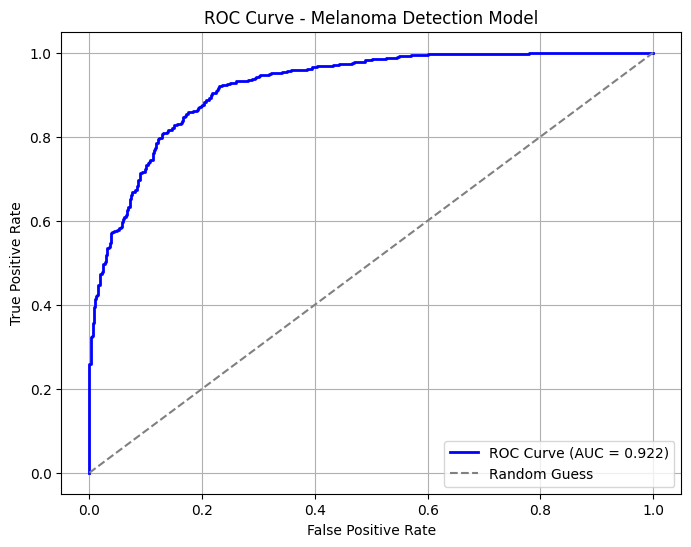

ROC curve saved!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Melanoma Detection Model')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/melanoma_v2/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")